In [2]:
from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple, Iterable
import numpy as np
import csv
from pathlib import Path
from scipy.optimize import root
from scipy.sparse import csr_matrix, diags, eye
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
# ============================================================
#  Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    """
    Parameters for one brain area.

    N      : number of neurons in this area
    s      : local sparsity, defined by C_i / N_i
             so each neuron in this area receives:
                 C_i = round(s * N)
             local recurrent inputs from the SAME area
    f_exc  : fraction of excitatory neurons in this area
             => N_E = round(f_exc * N), N_I = N - N_E
             => C_E = round(f_exc * C_i), C_I = C_i - C_E
    J_exc  : local excitatory synaptic weight in this area
    g_inh  : local inhibitory strength ratio
             local inhibitory weight = - g_inh * J_exc
    """
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    """
    Parameters for the full multi-area network.

    areas        : tuple of AreaParams, one per area

    s_cross      : shape (A, A)
                   s_cross[src, tgt] is the cross-area sparsity from area src to area tgt
                   Only EXCITATORY neurons in src can project to tgt.
                   For each target neuron in tgt:
                       C_{src->tgt} = round( s_cross[src, tgt] * N_E(src) )

    J_cross      : shape (A, A)
                   J_cross[src, tgt] is the excitatory weight from area src to area tgt

    allow_autapses : whether local self-connections are allowed
    activation     : "tanh" or "threshold_linear"
    phi_max        : used only if activation == "threshold_linear"
    dt, T          : simulation step and total simulation time
    seed           : random seed used to build connectivity
    """
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
#  Activation function
# ============================================================

def phi(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    """
    Rate nonlinearity.

    Kept intentionally simple:
    - tanh
    - threshold-linear with optional upper bound phi_max
    """
    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, (x + p.gamma))
        if np.isfinite(p.phi_max):
            y = np.minimum(p.phi_max, y)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")

# ============================================================
#  Derivative of activation
# ============================================================

def phi_prime(x: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    """
    激活函数导数：
    - tanh: phi'(x) = 1 - tanh(x)^2
    - threshold_linear: x+gamma>0 时导数为 1，否则为 0
      如果设了 phi_max，上饱和区导数为 0
    """
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")

# ============================================================
#  Population bookkeeping
#  Population order:
#     (area0,E), (area0,I), (area1,E), (area1,I), ...
# ============================================================

def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    """
    Build all index bookkeeping for the multi-area EI network.

    Returns a dictionary containing:
    - total neuron number
    - slices for each area and each population
    - local degrees C, C_E, C_I for each area
    """
    pops = []
    pop_sizes = []
    pop_slices = {}
    area_slices = {}
    area_stats = []

    start = 0
    for area_id, ap in enumerate(p.areas): # irretating among different areas
        # Number of excitatory / inhibitory neurons in this area
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        if N_E < 0 or N_I < 0:
            raise ValueError(f"Area {area_id}: invalid E/I split")

        # Local fixed in-degree in this area
        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        e_slice = slice(start, start + N_E)  # recording the neurons index
        pops.append((area_id, "E"))
        pop_slices[(area_id, "E")] = e_slice
        pop_sizes.append(N_E)
        start += N_E

        i_slice = slice(start, start + N_I)
        pops.append((area_id, "I"))
        pop_slices[(area_id, "I")] = i_slice
        pop_sizes.append(N_I)
        start += N_I

        area_slices[area_id] = slice(e_slice.start, i_slice.stop)

        area_stats.append({
            "area_id": area_id,
            "N": ap.N,
            "N_E": N_E,
            "N_I": N_I,
            "C": C,
            "C_E": C_E,
            "C_I": C_I,
            "J_E": ap.J_exc,
            "J_I": -ap.g_inh * ap.J_exc,
        })

    return {
        "pops": pops,
        "pop_sizes": np.asarray(pop_sizes, dtype=int),
        "N_total": start,
        "pop_slices": pop_slices,
        "area_slices": area_slices,
        "area_stats": area_stats,
    }


# ============================================================
#  Helpers
# ============================================================

def _validate_params(p: MultiAreaParams) -> None:
    """
    Check only the quantities that are essential for this construction.
    """
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")

    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def _candidate_pool(indices: np.ndarray, target_idx: int, allow_autapses: bool) -> np.ndarray:
    """
    Build the candidate presynaptic pool.

    If autapses are forbidden and target neuron belongs to this pool,
    remove itself from the candidate set.
    """
    if allow_autapses or len(indices) == 0:
        return indices

    # If target_idx is inside this pool, remove it; otherwise return as is
    if indices[0] <= target_idx <= indices[-1]:
        return indices[indices != target_idx]
    return indices


# ============================================================
#  Build sparse connectivity matrix
# ============================================================

def build_multi_area_connectivity(p: MultiAreaParams) -> Tuple[csr_matrix, Dict[str, Any]]:
    """
    Build the full sparse recurrent matrix W of the multi-area EI network.

    Construction rule:
    ------------------------------------------------------------
    Local (inside each area i):
      Each target neuron receives exactly:
          C_i   = round(s_i * N_i)
          C_E_i = round(f_i * C_i) excitatory local inputs
          C_I_i = C_i - C_E_i      inhibitory local inputs

      Local weights:
          +J_i               from local excitatory neurons
          -g_i * J_i         from local inhibitory neurons

    Cross-area (src -> tgt):
      Only excitatory neurons in source area src can project.
      Each target neuron in tgt receives exactly:
          C_{src->tgt} = round( s_{src->tgt} * N_E(src) )

      Cross-area weight:
          +J_{src->tgt}
    ------------------------------------------------------------

    Important:
    - This is a random sparse FIXED in-degree construction.
    - Randomness comes from random sampling of presynaptic neurons.
    - Sparsity is controlled by local s_i and cross-area s_{i->j}.
    """
    _validate_params(p)
    rng = np.random.default_rng(p.seed)
    info = population_info(p)

    A = len(p.areas)
    N_total = info["N_total"]
    pop_slices = info["pop_slices"]
    area_stats = info["area_stats"]

    rows = []
    cols = []
    data = []

    # --------------------------------------------------------
    # Loop over target areas
    # --------------------------------------------------------
    for tgt_area in range(A):
        stat_t = area_stats[tgt_area]

        tgt_all = np.arange(
            info["area_slices"][tgt_area].start,
            info["area_slices"][tgt_area].stop
        )
        tgt_exc = np.arange(
            pop_slices[(tgt_area, "E")].start,
            pop_slices[(tgt_area, "E")].stop
        )
        tgt_inh = np.arange(
            pop_slices[(tgt_area, "I")].start,
            pop_slices[(tgt_area, "I")].stop
        )

        C_E_local = stat_t["C_E"]
        C_I_local = stat_t["C_I"]
        w_E_local = stat_t["J_E"]
        w_I_local = stat_t["J_I"]

        # ----------------------------------------------------
        # For each target neuron, draw its presynaptic inputs
        # ----------------------------------------------------
        for i_tgt in tgt_all:
            # ---------- Local E candidates ----------
            exc_pool = _candidate_pool(
                tgt_exc, i_tgt, p.allow_autapses
            )

            # ---------- Local I candidates ----------
            inh_pool = _candidate_pool(
                tgt_inh, i_tgt, p.allow_autapses
            )

            # Check if requested fixed in-degree is feasible
            if C_E_local > len(exc_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_E={C_E_local} exceeds "
                    f"available local excitatory candidates={len(exc_pool)}"
                )
            if C_I_local > len(inh_pool):
                raise ValueError(
                    f"Area {tgt_area}: local C_I={C_I_local} exceeds "
                    f"available local inhibitory candidates={len(inh_pool)}"
                )

            # ---------- Draw local excitatory inputs ----------
            if C_E_local > 0:
                pre_exc = rng.choice(exc_pool, size=C_E_local, replace=False)
                rows.extend([i_tgt] * C_E_local)
                cols.extend(pre_exc.tolist())
                data.extend([w_E_local] * C_E_local)

            # ---------- Draw local inhibitory inputs ----------
            if C_I_local > 0:
                pre_inh = rng.choice(inh_pool, size=C_I_local, replace=False)
                rows.extend([i_tgt] * C_I_local)
                cols.extend(pre_inh.tolist())
                data.extend([w_I_local] * C_I_local)

            # ------------------------------------------------
            # Cross-area inputs:
            # only EXCITATORY neurons from src can project to tgt
            # ------------------------------------------------
            for src_area in range(A):
                if src_area == tgt_area:
                    continue

                src_exc = np.arange(
                    pop_slices[(src_area, "E")].start,
                    pop_slices[(src_area, "E")].stop
                )

                if len(src_exc) == 0:
                    continue

                s_ij = float(p.s_cross[src_area, tgt_area])
                if s_ij <= 0.0:
                    continue

                C_cross = int(round(s_ij * len(src_exc)))
                if C_cross == 0:
                    continue

                if C_cross > len(src_exc):
                    raise ValueError(
                        f"Cross ({src_area}->{tgt_area}): "
                        f"C_cross={C_cross} exceeds source excitatory pool={len(src_exc)}"
                    )

                pre_cross = rng.choice(src_exc, size=C_cross, replace=False)
                w_cross = float(p.J_cross[src_area, tgt_area])

                rows.extend([i_tgt] * C_cross)
                cols.extend(pre_cross.tolist())
                data.extend([w_cross] * C_cross)

    W = csr_matrix(
        (
            np.asarray(data, dtype=float),
            (np.asarray(rows, dtype=int), np.asarray(cols, dtype=int))
        ),
        shape=(N_total, N_total),
    )

    meta = {
        "N_total": N_total,
        "pops": info["pops"],
        "pop_sizes": info["pop_sizes"],
        "pop_slices": pop_slices,
        "area_slices": info["area_slices"],
        "area_stats": area_stats,
        "nnz": W.nnz,
    }
    return W, meta

# ============================================================
#  Lift population values -> neuron values
# ============================================================

def lift_population_values_to_neurons(values: np.ndarray, p: MultiAreaParams) -> np.ndarray:
    """
    Extend population vector length 2A into length N_total neuron vector.

    example:
      values = [x_(area0,E), x_(area0,I), x_(area1,E), x_(area1,I), ...]
      like for current I
    """
    info = population_info(p)
    pops = info["pops"]
    pop_slices = info["pop_slices"]
    N_total = info["N_total"]

    out = np.empty(N_total, dtype=float)
    for k, (area_id, cell_type) in enumerate(pops):
        out[pop_slices[(area_id, cell_type)]] = values[k]
    return out

# ============================================================
#  Full-network fixed point solver
#  Solve directly:
#       x* = W @ phi(x*)
#  i.e.
#       F(x) = -x + W @ phi(x) = 0
# ============================================================

def solve_full_fixed_point(
    W: csr_matrix,
    p: MultiAreaParams,
    x0_init: Optional[np.ndarray] = None,
    dt_fp: Optional[float] = None,
    tol: float = 1e-5,
    max_iter: int = 200000,
    verbose: bool = False,
    max_abs_x: float = 1e6,
    adaptive: bool = True,
) -> np.ndarray:
    """

    Solve:
        dx/dt = -x + W @ phi(x)
    and stop when the drift
        F(x) = -x + W @ phi(x)
    is sufficiently small
    """
    N = W.shape[0]

    if x0_init is None:
        x = np.zeros(N, dtype=float)
    else:
        x = np.asarray(x0_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x0_init must have shape ({N},)")

    if dt_fp is None:
        # use same step size as simulation
        dt_fp = p.dt

    if dt_fp <= 0.0:
        raise ValueError("dt_fp must be positive")

    prev_residual = np.inf

    for k in range(max_iter):
        r = phi(x, p)
        F = -x + W @ r

        # divergence check (drift)
        residual = np.max(np.abs(F))

        if verbose and (k < 10 or k % 1000 == 0):
            print(f"[iter {k:6d}] dt_fp = {dt_fp:.3e}, residual = {residual:.3e}, "
                  f"max|x| = {np.max(np.abs(x)):.3e}")

        if not np.all(np.isfinite(F)) or not np.all(np.isfinite(x)):
            if adaptive and dt_fp > 1e-8:
                dt_fp *= 0.5
                if verbose:
                    print(f"Non-finite encountered, reducing dt_fp to {dt_fp:.3e} and retrying.")
                # stable if start from 0, but could also continue from last step
                x = np.zeros(N, dtype=float) if x0_init is None else np.asarray(x0_init, dtype=float).copy()
                prev_residual = np.inf
                continue
            raise RuntimeError("Non-finite values encountered during fixed-point solve.")

        if residual < tol:
            if verbose:
                print(f"Converged at iter {k}: residual = {residual:.3e}")
            return x

        # Euler update
        x_new = x + dt_fp * F

        if not np.all(np.isfinite(x_new)) or np.max(np.abs(x_new)) > max_abs_x:
            if adaptive and dt_fp > 1e-8:
                dt_fp *= 0.5
                if verbose:
                    print(f"State exploded, reducing dt_fp to {dt_fp:.3e} and retrying.")
                continue
            raise RuntimeError(
                f"State diverged during fixed-point solve. "
                f"max|x_new|={np.max(np.abs(x_new)):.3e}"
            )

        # Automatically decrease step size if residual get worse
        if adaptive and residual > prev_residual * 1.2 and dt_fp > 1e-8:
            dt_fp *= 0.5
            if verbose:
                print(f"Residual increased, reducing dt_fp to {dt_fp:.3e}")
            continue

        x = x_new
        prev_residual = residual

    raise RuntimeError(
        f"Full fixed point solver did not converge within max_iter={max_iter}. "
        f"Last residual={residual:.3e}, max|x|={np.max(np.abs(x)):.3e}, dt_fp={dt_fp:.3e}"
    )

In [4]:
# ============================================================
#  Full stability matrix
# ============================================================

def build_full_stability_matrix(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> csr_matrix:
    """
        A = -I + W @ diag(phi'(x_star))
    """
    N = W.shape[0]
    x_star = np.asarray(x_star, dtype=float)

    if x_star.shape != (N,):
        raise ValueError(f"x_star must have shape ({N},)")

    gain = phi_prime(x_star, p)  # 每个 presynaptic neuron 的增益
    D = diags(gain, offsets=0, shape=(N, N), format="csr")

    A = -eye(N, format="csr") + W @ D
    return A

# ============================================================
#  Full spectra
# ============================================================

def compute_connectivity_spectrum(W: csr_matrix) -> np.ndarray:

    W_dense = W.toarray()
    eigvals = np.linalg.eigvals(W_dense)
    return eigvals


def compute_linearized_operator_spectrum(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:

    N = W.shape[0]
    gain = phi_prime(x_star, p)

    M = (W @ diags(gain, 0, shape=(N, N), format="csr")).toarray()
    eigvals = np.linalg.eigvals(M)
    return eigvals


def compute_stability_spectrum(
    W: csr_matrix,
    p: MultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:

    A = build_full_stability_matrix(W, p, x_star).toarray()
    eigvals = np.linalg.eigvals(A)
    return eigvals

In [5]:
'''
def simulate_rate_network_by_area(
    W: csr_matrix,
    p: MultiAreaParams,
    n_trace_per_area: int = 5,
    x_init: Optional[np.ndarray] = None,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
):
    """
    Simulate:
        dx/dt = -x + W @ phi(x)

    return:
    - t                : time axis, shape = (n_steps+1,)
    - traces_by_area   : dict[area_id] = array, shape = (n_steps+1, n_trace_this_area)
    - x_final          : final state
    - trace_idx_by_area: dict[area_id] = sampled neuron indices in this area
    """
    rng = np.random.default_rng(trace_seed)
    N = W.shape[0]
    n_steps = int(round(p.T / p.dt))

    if x_init is None:
        x = 1e-1 * rng.standard_normal(N)
    else:
        x = np.asarray(x_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x_init must have shape ({N},)")

    info = population_info(p)
    area_slices = info["area_slices"]
    A = len(p.areas)

    # --------------------------------------------------------
    # sample trace indices for each area
    # --------------------------------------------------------
    trace_idx_by_area = {}
    traces_by_area = {}

    for area_id in range(A):
        sl = area_slices[area_id]
        area_idx = np.arange(sl.start, sl.stop)
        n_pick = min(n_trace_per_area, len(area_idx))

        picked = rng.choice(area_idx, size=n_pick, replace=False)
        trace_idx_by_area[area_id] = picked

        traces_by_area[area_id] = np.empty((n_steps + 1, n_pick), dtype=float)
        traces_by_area[area_id][0] = phi(x[picked], p)

    t = np.linspace(0.0, p.T, n_steps + 1)

    # --------------------------------------------------------
    # simulation
    # --------------------------------------------------------
    for k in range(1, n_steps + 1):
        r = phi(x, p)
        x = x + p.dt * (-x + W @ r)

        for area_id in range(A):
            picked = trace_idx_by_area[area_id]
            traces_by_area[area_id][k] = phi(x[picked], p)

        if stop_if_abs_rate_exceeds is not None:
            current_max = max(
                np.max(np.abs(traces_by_area[area_id][k]))
                for area_id in range(A)
            )
            if current_max > stop_if_abs_rate_exceeds:
                t = t[:k + 1]
                for area_id in range(A):
                    traces_by_area[area_id] = traces_by_area[area_id][:k + 1]
                break

    return t, traces_by_area, x, trace_idx_by_area
'''

'\ndef simulate_rate_network_by_area(\n    W: csr_matrix,\n    p: MultiAreaParams,\n    n_trace_per_area: int = 5,\n    x_init: Optional[np.ndarray] = None,\n    trace_seed: int = 0,\n    stop_if_abs_rate_exceeds: Optional[float] = None,\n):\n    """\n    Simulate:\n        dx/dt = -x + W @ phi(x)\n\n    return:\n    - t                : time axis, shape = (n_steps+1,)\n    - traces_by_area   : dict[area_id] = array, shape = (n_steps+1, n_trace_this_area)\n    - x_final          : final state\n    - trace_idx_by_area: dict[area_id] = sampled neuron indices in this area\n    """\n    rng = np.random.default_rng(trace_seed)\n    N = W.shape[0]\n    n_steps = int(round(p.T / p.dt))\n\n    if x_init is None:\n        x = 1e-1 * rng.standard_normal(N)\n    else:\n        x = np.asarray(x_init, dtype=float).copy()\n        if x.shape != (N,):\n            raise ValueError(f"x_init must have shape ({N},)")\n\n    info = population_info(p)\n    area_slices = info["area_slices"]\n    A = len(p.

In [6]:
def simulate_rate_network_by_area(
    W: csr_matrix,
    p: MultiAreaParams,
    n_trace_per_area: int = 5,
    x_init: Optional[np.ndarray] = None,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
    init_mode: str = "uniform_rate",
    init_current_scale: float = 1.0,
    init_rate_low: float = 0.05,
    init_rate_high: float = 0.95,
):
    """
    Simulate:
        dx/dt = -x + W @ phi(x)

    Parameters
    ----------
    init_mode:
        "small_normal":
            old behavior, x_i ~ N(0, 0.1^2)

        "normal_current":
            x_i ~ N(0, init_current_scale^2)

        "uniform_current":
            x_i ~ Uniform(-init_current_scale, init_current_scale)

        "uniform_rate":
            sample initial firing rates uniformly inside the non-saturated region,
            then convert them back to currents by x = r - gamma.
            This is usually the best choice if you want visibly different initial rates.

    init_current_scale:
        scale used for "normal_current" and "uniform_current".

    init_rate_low, init_rate_high:
        lower and upper fractions of phi_max used for "uniform_rate".
        For example, if phi_max = 3.0, then rates are sampled from
        [0.05 * 3.0, 0.95 * 3.0].
    """

    rng = np.random.default_rng(trace_seed)
    N = W.shape[0]
    n_steps = int(round(p.T / p.dt))

    # --------------------------------------------------------
    # initialize state
    # --------------------------------------------------------
    if x_init is None:
        if init_mode == "small_normal":
            # Original behavior
            x = 1e-1 * rng.standard_normal(N)

        elif init_mode == "normal_current":
            # Larger random fluctuations in current space
            x = init_current_scale * rng.standard_normal(N)

        elif init_mode == "uniform_current":
            # Uniformly distributed currents
            x = rng.uniform(
                low=-init_current_scale,
                high=init_current_scale,
                size=N,
            )

        elif init_mode == "uniform_rate":
            # Recommended:
            # initialize rates broadly but avoid immediate saturation.
            if not np.isfinite(p.phi_max):
                raise ValueError(
                    "init_mode='uniform_rate' requires finite p.phi_max. "
                    "Use init_mode='normal_current' or 'uniform_current' if phi_max=np.inf."
                )

            r_low = init_rate_low * p.phi_max
            r_high = init_rate_high * p.phi_max

            r0 = rng.uniform(low=r_low, high=r_high, size=N)

            # For phi(x) = clip(gamma + x, 0, phi_max),
            # the inverse inside the linear region is x = r - gamma.
            x = r0 - p.gamma

        else:
            raise ValueError(
                "init_mode must be one of: "
                "'small_normal', 'normal_current', 'uniform_current', 'uniform_rate'."
            )

    else:
        x = np.asarray(x_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x_init must have shape ({N},)")

    info = population_info(p)
    area_slices = info["area_slices"]
    A = len(p.areas)

    # --------------------------------------------------------
    # sample trace indices for each area
    # --------------------------------------------------------
    trace_idx_by_area = {}
    traces_by_area = {}
    mean_rate_by_area = {}

    for area_id in range(A):
        sl = area_slices[area_id]
        area_idx = np.arange(sl.start, sl.stop)
        n_pick = min(n_trace_per_area, len(area_idx))
    
        picked = rng.choice(area_idx, size=n_pick, replace=False)
        trace_idx_by_area[area_id] = picked
    
        traces_by_area[area_id] = np.empty((n_steps + 1, n_pick), dtype=float)
        traces_by_area[area_id][0] = phi(x[picked], p)
    
        # 新增：保存该 area 的平均 firing rate
        mean_rate_by_area[area_id] = np.empty(n_steps + 1, dtype=float)
        mean_rate_by_area[area_id][0] = phi(x[sl], p).mean()
        
    t = np.linspace(0.0, p.T, n_steps + 1)

    # --------------------------------------------------------
    # simulation
    # --------------------------------------------------------
    for k in range(1, n_steps + 1):
        r = phi(x, p)
        x = x + p.dt * (-x + W @ r)
        
        for area_id in range(A):
            picked = trace_idx_by_area[area_id]
            sl = area_slices[area_id]
        
            traces_by_area[area_id][k] = phi(x[picked], p)
        
            # 新增：记录该 area 全体神经元平均活动
            mean_rate_by_area[area_id][k] = phi(x[sl], p).mean()

        if stop_if_abs_rate_exceeds is not None:
            current_max = max(
                np.max(np.abs(traces_by_area[area_id][k]))
                for area_id in range(A)
            )
            if current_max > stop_if_abs_rate_exceeds:
                t = t[:k + 1]
                for area_id in range(A):
                    traces_by_area[area_id] = traces_by_area[area_id][:k + 1]
                    mean_rate_by_area[area_id] = mean_rate_by_area[area_id][:k + 1]
                break

    return t, traces_by_area, mean_rate_by_area, x, trace_idx_by_area

In [7]:
def plot_multi_area_fig_full_separate_areas(
    W_base: csr_matrix,
    p: MultiAreaParams,
    alphas,
    n_trace_per_area: int = 5,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
    spectrum_mode: str = "stability",   # "connectivity", "linearized", "stability"
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
):
    """
    each figure:
    - panel correspond to different alpha
    - main part includes randomly sampled dynamics within area

    return:
    - figs: dict[area_id] = figure
    """
    alphas = list(alphas)
    n = len(alphas)
    A = len(p.areas)

    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    # --------------------------------------------------------
    # sampling among global intensity scaling factor alpha, could ignore
    # --------------------------------------------------------
    results = []
    x_star_prev = None

    for alpha in alphas:
        W_eff = alpha * W_base

        # simulate once
        t, traces_by_area, mean_rate_by_area, x_final, trace_idx_by_area = simulate_rate_network_by_area(
            W=W_eff,
            p=p,
            n_trace_per_area=n_trace_per_area,
            trace_seed=trace_seed,
            init_mode="small_normal",
            init_rate_low=0.05,
            init_rate_high=0.95,
            #stop_if_abs_rate_exceeds=stop_if_abs_rate_exceeds,
        )

        # spectrum once
        if spectrum_mode == "connectivity":
            eigvals = compute_connectivity_spectrum(W_eff)
            stability_re_line = 1.0

        else:
            x_star = solve_full_fixed_point(
                W=W_eff,
                p=p,
                x0_init=x_star_prev,
            )
            x_star_prev = x_star.copy()

            if spectrum_mode == "linearized":
                eigvals = compute_linearized_operator_spectrum(
                    W=W_eff,
                    p=p,
                    x_star=x_star,
                )
                stability_re_line = 1.0

            elif spectrum_mode == "stability":
                eigvals = compute_stability_spectrum(
                    W=W_eff,
                    p=p,
                    x_star=x_star,
                )
                stability_re_line = 0.0

            else:
                raise ValueError("spectrum_mode must be 'connectivity', 'linearized', or 'stability'")

        results.append({
            "alpha": alpha,
            "t": t,
            "traces_by_area": traces_by_area,
            "mean_rate_by_area": mean_rate_by_area,
            "trace_idx_by_area": trace_idx_by_area,
            "eigvals": eigvals,
            "stability_re_line": stability_re_line,
        })

    # --------------------------------------------------------
    # Draw graphs for each area
    # --------------------------------------------------------
    figs = {}

    for area_id in range(A):
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(col_width * ncols, row_height * nrows),
            constrained_layout=True
        )
        axes = np.atleast_1d(axes).ravel()

        for i, res in enumerate(results):
            ax = axes[i]

            t = res["t"]
            traces = res["traces_by_area"][area_id]
            mean_rate = res["mean_rate_by_area"][area_id]
            eigvals = res["eigvals"]
            stability_re_line = res["stability_re_line"]
            alpha = res["alpha"]


            # main traces for this area only
            ax.plot(t, traces, linewidth=1.2, alpha=0.6)
            
            # area average activity
            mean_rate = res["mean_rate_by_area"][area_id]
            ax.plot(
                t,
                mean_rate,
                color="black",
                linewidth=2.5,
                label="area mean",
            )
            
            ax.set_title(f"Area {area_id}", fontsize=11)
            ax.grid(alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.legend(frameon=False, fontsize=8)



            if i % ncols == 0:
                ax.set_ylabel(r"Firing rate $\phi(x_i)$")
            else:
                ax.set_ylabel("")

            if i // ncols == nrows - 1:
                ax.set_xlabel("t")
            else:
                ax.set_xlabel("")
            '''
            # ---------- inset spectrum of full network ----------
            iax = inset_axes(ax, width="33%", height="55%", loc="upper left", borderpad=1.0)
            iax.scatter(eigvals.real, eigvals.imag, s=2, alpha=0.25)
            iax.axvline(stability_re_line, color="red", linestyle="--", linewidth=1.0)
            iax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
            iax.axvline(0.0, color="k", linewidth=0.5, alpha=0.35)
            iax.set_xticks([])
            iax.set_yticks([])
            iax.set_aspect("equal", "box")
            '''
        for j in range(n, nrows * ncols):
            axes[j].axis("off")

        figs[area_id] = fig

    return figs

In [8]:
NE = 1600  # because N=2000, f_exc=0.8

def make_case(case_id: int):
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.040, g_inh=4.5)
    area2 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.040, g_inh=4.5)

    s_cross = np.zeros((2, 2), dtype=float)
    J_cross = np.zeros((2, 2), dtype=float)

    activation = "threshold_linear"
    phi_max = np.inf
    gamma = 0.5

    if case_id == 1:   # stable FF stable
        area1 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        s_cross[0, 1] = 2 / NE
        J_cross[0, 1] = 0.30
        #activation = "threshold_linear"
        #phi_max = 0.5

    elif case_id == 2: # stable FF unstable
        area1 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.050, 4.5)
        s_cross[0, 1] = 2 / NE
        J_cross[0, 1] = 0.30
        activation = "threshold_linear"
        phi_max = 0.4

    elif case_id == 3: # unstable FF stable
        area1 = AreaParams(2000, 0.05, 0.8, 0.050, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        s_cross[0, 1] = 2 / NE
        J_cross[0, 1] = 0.30

    elif case_id == 4: # 2 stable + feedback -> unstable
        area1 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        s_cross[0, 1] = 2 / NE
        s_cross[1, 0] = 2 / NE
        J_cross[0, 1] = 0.69
        J_cross[1, 0] = 0.69

    elif case_id == 5: # 1 stable + 1 unstable + feedback -> stable (nonlinear stabilization)
        area1 = AreaParams(2000, 0.05, 0.8, 0.0402, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.0537, 4.5)
        s_cross[0, 1] = 1 / NE
        s_cross[1, 0] = 1 / NE
        J_cross[0, 1] = 0.80
        J_cross[1, 0] = 0.50
        activation = "threshold_linear"
        phi_max = 0.6

    elif case_id == 6: # 1 stable + 1 unstable + feedback -> unstable
        area1 = AreaParams(2000, 0.05, 0.8, 0.040, 4.5)
        area2 = AreaParams(2000, 0.05, 0.8, 0.050, 4.5)
        s_cross[0, 1] = 2 / NE
        s_cross[1, 0] = 2 / NE
        J_cross[0, 1] = 0.30
        J_cross[1, 0] = 0.30

    return MultiAreaParams(
        areas=(area1, area2),
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=False,
        activation=activation,
        phi_max=phi_max,
        gamma=gamma,
        dt=0.01,
        T=300.0,
        seed=1,
    )

Network meta:
N_total = 8000
Fraction of non-zero entries = 0.0175
max Re(lambda_connectivity) = 1.116339826901019


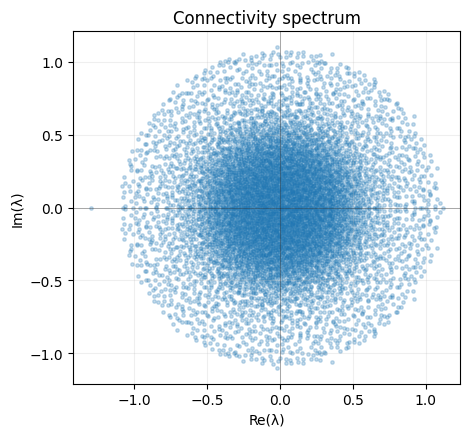

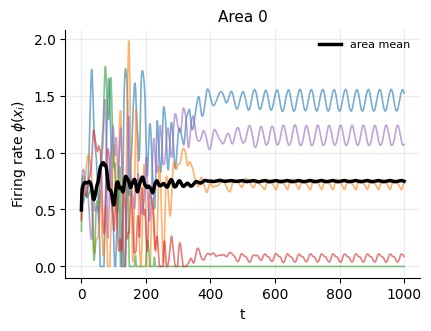

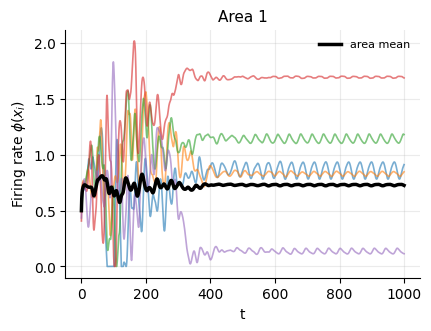

In [9]:
def main():
    #'''
    areas = (
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.05, g_inh=4.5),
        AreaParams(N=4000, s=0.025, f_exc=0.8, J_exc=0.05, g_inh=4.5),
    )

    A = len(areas)

    s_cross = np.zeros((A, A))
    J_cross = np.zeros((A, A))

    s_cross[0, 1] = 0.0125
    J_cross[0, 1] = 0.02

    s_cross[1, 0] = 0.0125
    J_cross[1, 0] = 0.02


    p = MultiAreaParams(
        areas=areas,
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5, 
        dt=0.005,
        T=1000.0,
        seed=0,
    )
    #'''
    # case_id = 2
    # p = make_case(case_id)

    # base connectivity
    W_base, meta = build_multi_area_connectivity(p)
    print("Network meta:")
    print("N_total =", meta["N_total"])
    print("Fraction of non-zero entries =", meta["nnz"]/(meta["N_total"]*meta["N_total"]))

    # Draw spectrum of W
    eig_W = compute_connectivity_spectrum(W_base)
    print("max Re(lambda_connectivity) =", np.max(eig_W.real))
    plt.figure(figsize=(5, 5))
    plt.scatter(eig_W.real, eig_W.imag, s=6, alpha=0.25)
    plt.axvline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.axhline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.title(f"Connectivity spectrum")
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.gca().set_aspect("equal", "box")
    plt.grid(alpha=0.2)
    plt.show()

    # # Solving fixed point and Jacobian
    # alpha0 = 1.0 # alpha gives global intensity scaling factor, but could be ignored most of time 
    # W_eff = alpha0 * W_base

    # x_star = solve_full_fixed_point(W=W_eff, p=p)

    # print("\nFull fixed point solved.")

    # # Draw spectrum of linearized W
    # eig_L = compute_linearized_operator_spectrum(W_eff, p, x_star)
    # print("max Re(lambda_linearized) =", np.max(eig_L.real))
    # plt.figure(figsize=(5, 5))
    # plt.scatter(eig_L.real, eig_L.imag, s=6, alpha=0.25)
    # plt.axvline(0.0, color="k", linewidth=0.6, alpha=0.35)
    # plt.axhline(0.0, color="k", linewidth=0.6, alpha=0.35)
    # plt.title(f"Linearized spectrum")
    # plt.xlabel("Re(λ)")
    # plt.ylabel("Im(λ)")
    # plt.gca().set_aspect("equal", "box")
    # plt.grid(alpha=0.2)
    # plt.show()


    # eig_jac = compute_stability_spectrum(
    #     W=W_eff,
    #     p=p,
    #     x_star=x_star,
    #     )
    # print("max Re(lambda_stability) =", np.max(eig_jac.real))
    
    alphas = [1.0]

    figs = plot_multi_area_fig_full_separate_areas(
        W_base=W_base,
        p=p,
        alphas=alphas,
        n_trace_per_area=5,   
        trace_seed=10,
        stop_if_abs_rate_exceeds=500.0,
        spectrum_mode="connectivity",   # or "connectivity", "stability"
    )
    
    for area_id, fig in figs.items():
        #fig.suptitle(f"Dynamics of sampled neurons from Area {area_id}", fontsize=14)
        plt.show()
    
if __name__ == "__main__":
    main()